In [1]:
import torch
from torch.utils.data import Dataset
from PIL import Image
import pandas as pd
from torchvision import transforms
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt 
import os 


class GoalDataset(Dataset):
    def __init__(self, dataframe,transform=None):
        self.data = dataframe
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        img_path = self.data.iloc[idx, 0]
        label = int(self.data.iloc[idx, 1])
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        return image, label

In [2]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name())

True
NVIDIA L40S-12C


In [3]:
import os
import pandas as pd

def create_dataframe_shot_only(dataset_root):
    rows = []

    for shot_folder in os.listdir(dataset_root):
        folder_path = os.path.join(dataset_root, shot_folder)
        if not os.path.isdir(folder_path):
            continue

        label_path = os.path.join(folder_path, "label.txt")
        if not os.path.exists(label_path):
            print(f"Etiqueta no encontrada en {folder_path}")
            continue
        with open(label_path, "r") as f:
            label = int(f.read().strip())

        shot_img_path = os.path.join(folder_path, "frame_shot.jpg")
        if os.path.exists(shot_img_path):
            rows.append([shot_img_path, label])
        else:
            print(f"Frame shot no trobat en {folder_path}")

    df = pd.DataFrame(rows, columns=["image_path", "label"])
    return df


dataset_path= "./Frames_Bons_Definitius"
df = create_dataframe_shot_only(dataset_path)

Data=GoalDataset(df)

FileNotFoundError: [Errno 2] No such file or directory: './Frames_Bons_Definitius'

In [4]:
image_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406],
                             [0.229, 0.224, 0.225])
    ])
}


In [5]:
def get_dataloaders(df, batch_size=32, split_ratio=0.8):
    dataset = GoalDataset(df, transform=image_transforms['train'])

    train_size = int(split_ratio * len(dataset))
    val_size = len(dataset) - train_size

    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

    # Replace transforms for validation set
    val_dataset.dataset.transform = image_transforms['val']

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    return train_loader, val_loader


In [6]:


class CoordConvLayer(nn.Module):
   def __init__(self, with_r=False):
       super(CoordConvLayer, self).__init__()
       self.with_r = with_r


   def forward(self, x):
       """
       Añade canales coordenados a la imagen.
       x: batch x channels x height x width
       retorna: batch x (channels + 2 or 3) x height x width
       """
       batch_size, _, height, width = x.size()
       device = x.device


       xx_channel = torch.linspace(-1, 1, steps=width, device=device).repeat(1, height, 1)
       yy_channel = torch.linspace(-1, 1, steps=height, device=device).repeat(1, width, 1).transpose(1, 2)


       xx_channel = xx_channel.expand(batch_size, 1, height, width)
       yy_channel = yy_channel.expand(batch_size, 1, height, width)


       ret = torch.cat([x, xx_channel, yy_channel], dim=1)


       if self.with_r:
           rr = torch.sqrt(xx_channel ** 2 + yy_channel ** 2)
           ret = torch.cat([ret, rr], dim=1)


       return ret


class ModelCNN(nn.Module):
   def __init__(self):
       super(ModelCNN, self).__init__()
       self.coordconv = CoordConvLayer()  
       self.conv1 = nn.Conv2d(5, 16, 3,padding=1)  
       self.pool = nn.MaxPool2d(2, 2)
       self.conv2 = nn.Conv2d(16, 32, 3,padding=1)
       self.fc1 = nn.Linear(32 * 56 * 56, 128)
       self.fc2 = nn.Linear(128, 1)


   def forward(self, x):
       x = self.coordconv(x)                       # Agrega los canales coordenados
       x = self.pool(F.relu(self.conv1(x)))       # 112x112
       x = self.pool(F.relu(self.conv2(x)))       # 56x56
       x = x.view(-1, 32 * 56 * 56)
       x = F.relu(self.fc1(x))
       x = torch.sigmoid(self.fc2(x))
       return x

In [11]:
class WeightedLoss(nn.Module):
    def __init__(self, image_size, sigma=1.0):
        super(WeightedLoss, self).__init__()
        self.image_size = image_size
        self.sigma = sigma
        self.register_buffer('gaussian_mask', self.create_gaussian_mask())

    def create_gaussian_mask(self):
        x = torch.arange(0, self.image_size[1]).float()
        y = torch.arange(0, self.image_size[0]).float()
        xx, yy = torch.meshgrid(y, x, indexing='ij')
        cx, cy = self.image_size[1] // 2, self.image_size[0] // 2
        distance = (xx - cx)**2 + (yy - cy)**2
        gaussian = torch.exp(-distance / (2 * self.sigma ** 2))
        return gaussian / gaussian.sum()

    def forward(self, output, target, input_image):
        """
        output: [B, 1] logits
        target: [B, 1] ground truth (float)
        input_image: [B, C, H, W]
        """

        B = output.shape[0]
        # Convert to grayscale or sum channels
        with torch.no_grad():
            grayscale = input_image[:, :3].mean(dim=1)  # [B, H, W] — assuming RGB in channels 0–2
            importance = (grayscale * self.gaussian_mask).view(B, -1).sum(dim=1)  # [B]
            importance = importance / importance.sum()  # Normalize importance per batch

        bce = F.binary_cross_entropy_with_logits(output.view(-1), target.view(-1), reduction='none')  # [B]
        weighted_loss = (importance * bce).sum()  # scalar

        return weighted_loss


In [12]:
def train(epoch, criterion, model, optimizer, loader,device):

    total_loss = 0.0

    model.train()

    for batch_idx, (data, target) in enumerate(loader):

        optimizer.zero_grad()

        data, target = data.to(device), target.to(device)

        output = model(data)
        output = output.view(-1)  
        loss = criterion(output, target.float(),data)
        loss.backward()
        optimizer.step()
        if batch_idx % 100 == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch, batch_idx * len(data), len(loader.dataset),
                100. * batch_idx / len(loader), loss.item()))


        total_loss += loss.item()  
    return total_loss / len(loader.dataset)


In [18]:

        
def validate(criterion, model, loader, device):
    val_loss = 0
    correct = 0

    model.eval()
    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.to(device)
            output = model(data).view(-1)  
            loss = criterion(output, target.float(),data)
            val_loss += loss.item()

            pred = (output >= 0.5).long()  # predicción binaria
            correct += pred.eq(target).sum().item()

    val_loss /= len(loader.dataset)
    accuracy = 100. * correct / len(loader.dataset)
    print(f'\nTest set: Average loss: {val_loss:.4f}, Accuracy: {correct}/{len(loader.dataset)} ({accuracy:.0f}%)\n')

    return val_loss



In [19]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)
torch.backends.cudnn.benchmark = True
learning_rate = 1e-4
lambda_l2 = 1e-5
momentum = 0.5
epoch=10
torch.manual_seed(0)
model=ModelCNN()
model.to(device)
train_loader, val_loader = get_dataloaders(df, batch_size=32)
criterion = WeightedLoss((224,224)).to(device)
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate, momentum=momentum, weight_decay=lambda_l2)

cuda


Train Epoch: 0 [0/1134 (0%)]	Loss: 0.960203

Test set: Average loss: 0.0290, Accuracy: 240/284 (85%)

Train Epoch: 1 [0/1134 (0%)]	Loss: 0.879140

Test set: Average loss: 0.0284, Accuracy: 240/284 (85%)

Train Epoch: 2 [0/1134 (0%)]	Loss: 0.908075

Test set: Average loss: 0.0278, Accuracy: 240/284 (85%)

Train Epoch: 3 [0/1134 (0%)]	Loss: 0.884289

Test set: Average loss: 0.0272, Accuracy: 240/284 (85%)

Train Epoch: 4 [0/1134 (0%)]	Loss: 0.877894

Test set: Average loss: 0.0267, Accuracy: 240/284 (85%)

Train Epoch: 5 [0/1134 (0%)]	Loss: 0.899543

Test set: Average loss: 0.0262, Accuracy: 240/284 (85%)

Train Epoch: 6 [0/1134 (0%)]	Loss: 0.855090

Test set: Average loss: 0.0258, Accuracy: 240/284 (85%)

Train Epoch: 7 [0/1134 (0%)]	Loss: 0.837859

Test set: Average loss: 0.0253, Accuracy: 240/284 (85%)

Train Epoch: 8 [0/1134 (0%)]	Loss: 0.792279

Test set: Average loss: 0.0250, Accuracy: 240/284 (85%)

Train Epoch: 9 [0/1134 (0%)]	Loss: 0.790505

Test set: Average loss: 0.0247, Accur

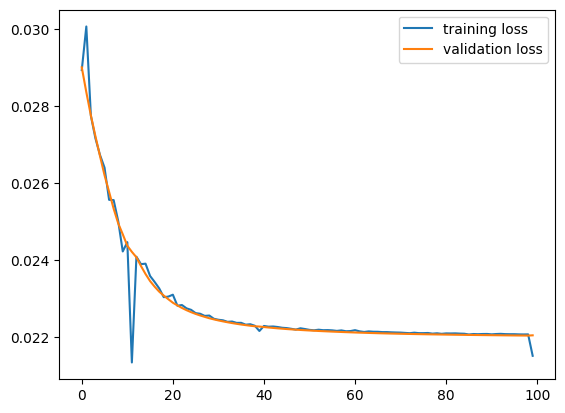

In [20]:
losses= {"train":[], "validate":[] }
losses = {"train": [], "val": []}

for epoch in range(100):

    train_loss = train(epoch, criterion, model, optimizer, train_loader, device)
    val_loss = validate(criterion, model, val_loader, device)
    losses["train"].append(train_loss)
    losses["val"].append(val_loss)

plt.plot(losses["train"], label="training loss")
plt.plot(losses["val"], label="validation loss")

plt.legend()
plt.pause(0.000001)
plt.show()
